In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

## Q1

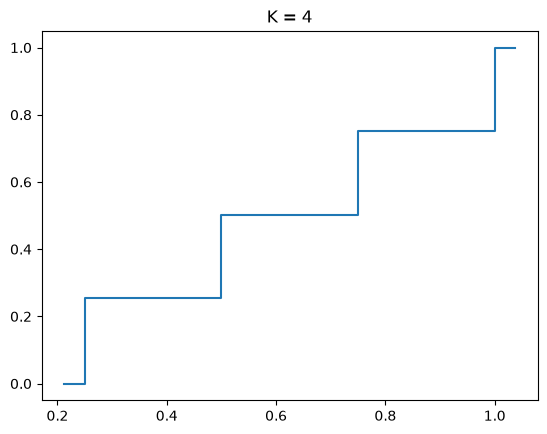

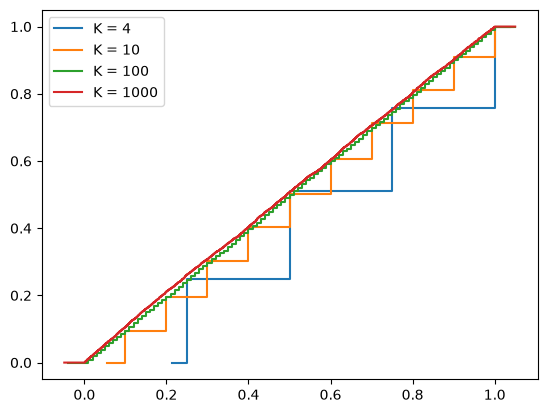

In [5]:
n = 5_000

def draw(K, n):
    grid = np.arange(1, K + 1) / K        # sets up the grid
    idx = stats.randint(0, K).rvs(size=n)    # draws from the grid      
    return grid[idx]

# shows the ecdf of a small k
fig, ax = plt.subplots()
stats.ecdf(draw(4, n)).cdf.plot(ax)
ax.set_title("K = 4")
plt.show()

# increases the k
fig, ax = plt.subplots()
for K in [4, 10, 100, 1000]:
    stats.ecdf(draw(K, n)).cdf.plot(ax, label=f"K = {K}")
ax.legend()
plt.show()

As the k increases the distribution looks close to a uniform distribution.

## Q3

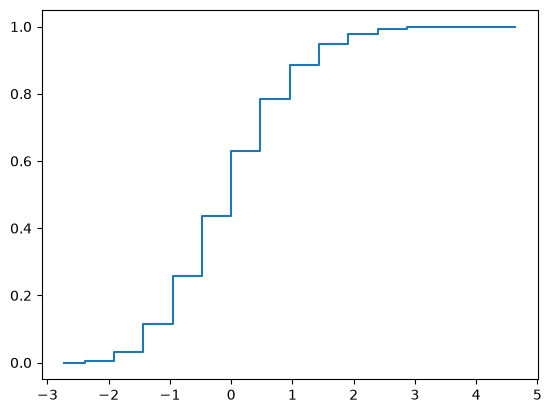

In [12]:
n = 40
p = 1/8
b = 5_000

#flip the coin 40 times
z = []
for _ in range(b):                                  # Step 4: repeat b times
    flips = stats.bernoulli(p).rvs(size=n)         # flip the coin 40 times
    heads = flips.sum()
    z.append((heads - n * p) / np.sqrt(n * p * (1 - p))) 


fig, ax = plt.subplots() # plot the ecdf
stats.ecdf(z).cdf.plot(ax)
plt.show()

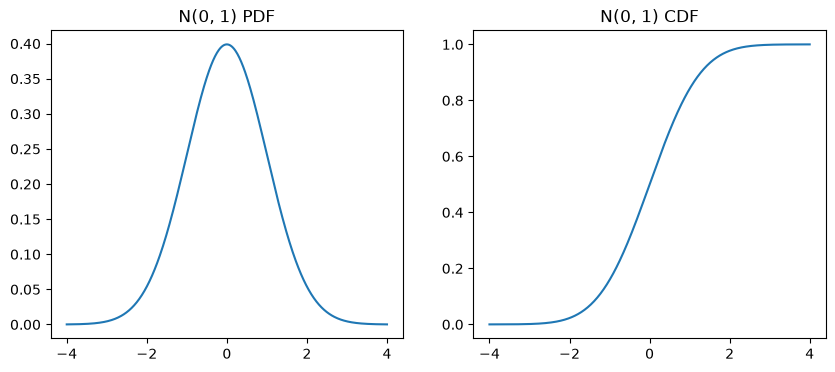

In [7]:
x = np.linspace(-4, 4, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, stats.norm.pdf(x, loc=0, scale=1))
ax1.set_title("N(0, 1) PDF")
ax2.plot(x, stats.norm.cdf(x, loc=0, scale=1))
ax2.set_title("N(0, 1) CDF")
plt.show()

5. from the graph it looks like the distribution is a normal distribution's CDF as shown above. 
6. As p is adjusted the ecdf becomes less obviously a normal distribution and looks more skewed. I ran the code block with several differnt values of p.

## Q4

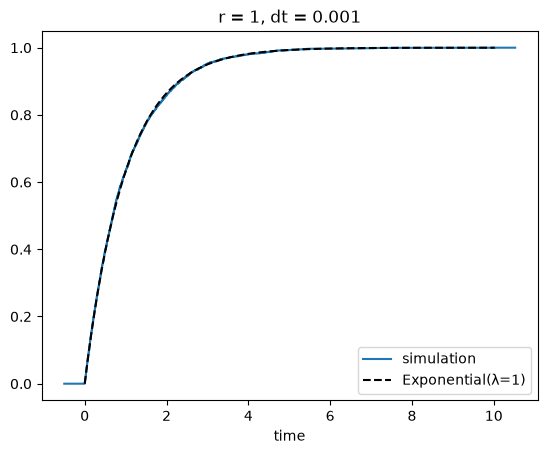

In [3]:
n = 5_000
dt = 1e-3
rng = np.random.default_rng()

def simulate(r, dt, n):
    periods = np.zeros(n, dtype=int) # period in which each process terminates
    alive = np.ones(n, dtype=bool)
    t = 0
    while alive.any(): # step 1: run until every process terminates
        t += 1
        idx = np.flatnonzero(alive)
        dies = rng.random(idx.size) < r * dt # terminate with probability r*dt
        periods[idx[dies]] = t
        alive[idx[dies]] = False
    return periods * dt # step 2: convert periods to time

r = 1
times = simulate(r, dt, n)
x = np.linspace(0, times.max(), 500)

fig, ax = plt.subplots()
stats.ecdf(times).cdf.plot(ax, label="simulation")
ax.plot(x, stats.expon.cdf(x, scale=1/r), 'k--', label=f"Exponential(λ={r})")
ax.set_title(f"r = {r}, dt = {dt}")
ax.set_xlabel("time")
ax.legend()
plt.show()





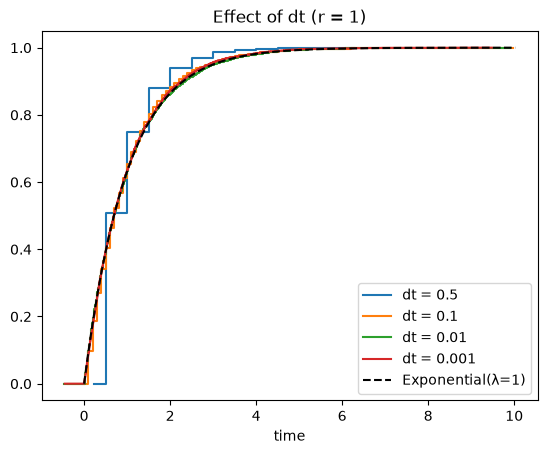

In [4]:
# step 4: shrinking dt
fig, ax = plt.subplots()
for d in [0.5, 0.1, 0.01, 1e-3]:
    stats.ecdf(simulate(r, d, n)).cdf.plot(ax, label=f"dt = {d}")
ax.plot(x, stats.expon.cdf(x, scale=1/r), 'k--', label="Exponential(λ=1)")
ax.set_title("Effect of dt (r = 1)")
ax.set_xlabel("time")
ax.legend()
plt.show()

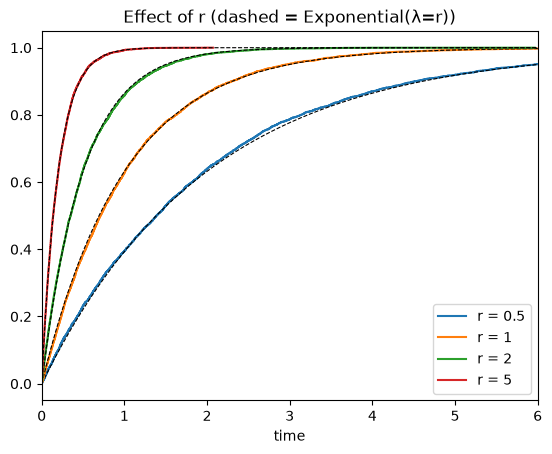

In [5]:
# step 5: adjusting r
fig, ax = plt.subplots()
x = np.linspace(0, 6, 500)
for r in [0.5, 1, 2, 5]:
    stats.ecdf(simulate(r, dt, n)).cdf.plot(ax, label=f"r = {r}")
    ax.plot(x, stats.expon.cdf(x, scale=1/r), 'k--', lw=0.8)
ax.set_xlim(0, 6)
ax.set_title("Effect of r (dashed = Exponential(λ=r))")
ax.set_xlabel("time")
ax.legend()
plt.show()

The simulation produces a graph similar to the exponential distribution. 

When r is small, the distribution stretches out. A large r is concentrated at lower times.

## Q6

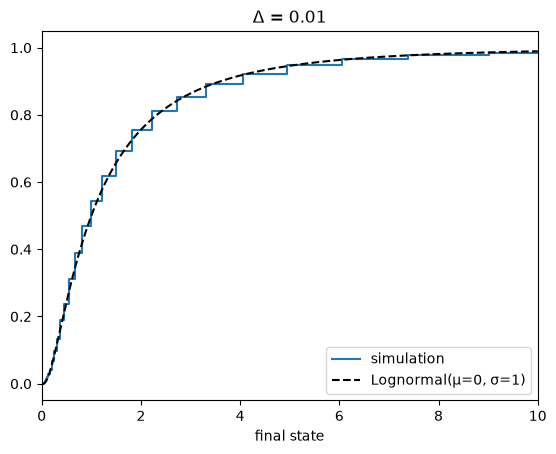

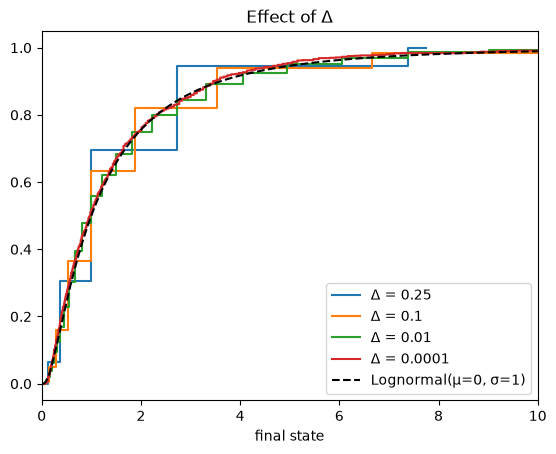

In [ ]:
B = 1_000
rng = np.random.default_rng()

def simulate(delta, B):
    steps = int(round(1 / delta))   
    up = rng.random((B, steps)) < 0.5  
    factors = np.where(up, np.exp(np.sqrt(delta)), np.exp(-np.sqrt(delta)))
    return factors.prod(axis=1)                


delta = 1/100
final = simulate(delta, B)
x = np.linspace(0.01, 10, 500)

fig, ax = plt.subplots()
stats.ecdf(final).cdf.plot(ax, label="simulation")
ax.plot(x, stats.lognorm.cdf(x, s=1, scale=np.exp(0)), 'k--', label="Lognormal(μ=0, σ=1)")
ax.set_xlim(0, 10)
ax.set_title(f"Δ = {delta}")
ax.set_xlabel("final state")
ax.legend()
plt.show()


fig, ax = plt.subplots()
for d in [1/4, 1/10, 1/100, 1/10_000]:
    stats.ecdf(simulate(d, B)).cdf.plot(ax, label=f"Δ = {d:g}")
ax.plot(x, stats.lognorm.cdf(x, s=1, scale=1), 'k--', label="Lognormal(μ=0, σ=1)")
ax.set_xlim(0, 10)
ax.set_title("Effect of Δ")
ax.set_xlabel("final state")
ax.legend()
plt.show()


The distribution looks close to the lognormal distribution as the delta moves towards 0.